In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [53]:
file_path = 'LH_metal_DB_v1.12.csv'  # 替换为你的文件路径
df = pd.read_csv(file_path)

In [54]:
df.loc[:, 'TOK'] = df['TOK'].str.strip()
df['IP']=df['IP'].abs()/1000000

reference_dict = {
    1.00:  "Hydrogen",
    2.00:  "Deuterium",
    2.50:  "Deuterium and tritium",
    3.00:  "3He or tritium",
    4.00:  "4He",
    14.01: "Nitrogen"
}

# 定义一个函数，用来根据某一观测值PGASA，返回对应的分类名称
def categorize_pgasa(value, ref_dict, tolerance=0.2):
    """
    value: 待分类的数值
    ref_dict: {参考值: 分类名称}
    tolerance: 容忍度，即 |value - 参考值| 需小于等于该值才视为同一类
    """
    # 1) 找到离 value 最近的参考值
    closest_ref = min(ref_dict.keys(), key=lambda x: abs(x - value))
    # 2) 判断两者差值是否在容忍度以内
    if abs(closest_ref - value) <= tolerance:
        return ref_dict[closest_ref]
    else:
        return np.nan  # 或者 "Other"

# 将 categorize_pgasa 应用于 df["PGASA"] 列，生成新的分类列
df["Category"] = df["PGASA"].apply(lambda x: categorize_pgasa(x, reference_dict, tolerance=0.1))

# 如果需要查看分类结果
print(df)



subset1 = df[df['TOK'] == 'CMOD']
subset2 = df[df['TOK'] == 'AUG']
subset3 = df[df['TOK'] == 'JET']

subset2['IP']


      TOK        SHOT      TIME PHASE  PGASA      RGEO      AMIN    KAPPA  \
0    CMOD  1050428004   0.63461    LH  2.000  0.672389  0.216421  1.69737   
1    CMOD  1050428007   0.66603    LH  2.000  0.670773  0.217660  1.67073   
2    CMOD  1050621015   0.91039    LH  2.000  0.672785  0.217388  1.67962   
3    CMOD  1050621029   0.85420    LH  2.000  0.670869  0.217080  1.69789   
4    CMOD  1050623008   0.80070    LH  2.000  0.678764  0.213690  1.44202   
..    ...         ...       ...   ...    ...       ...       ...      ...   
685   JET       90527  50.99500    LH  1.962  2.900090  0.933780  1.66731   
686   JET       90528  55.16500    LH  1.916  2.901440  0.933319  1.66831   
687   JET       90737  54.56500    LH  1.940  2.901330  0.934255  1.66599   
688   JET       90738  54.46500    LH  1.961  2.898400  0.937640  1.65848   
689   JET       90742  52.16500    LH  1.983  2.900930  0.933565  1.66813   

       SPLASMA CONFIG  ...       PL     PLTH    PFLOSS PRADCORE    DIVCON  

77     1.0040
78     1.0030
79     0.9987
80     1.0000
81     0.9997
        ...  
324    0.5993
325    0.7961
326    0.7967
327    0.7947
328    0.7952
Name: IP, Length: 252, dtype: float64

In [5]:
subset2

,TOK,SHOT,TIME,PHASE,PGASA,RGEO,AMIN,KAPPA,SPLASMA,CONFIG,...,PL,PLTH,PFLOSS,PRADCORE,DIVCON,FRACNMIN,LHTIME,AUXHEAT,SELEC2024,Category
77,AUG,23250,1.570,LH,2.0,1.621,0.5176,1.752,44.56,SN(L),...,1685000,1660000,0.0,457100,STANDARD,1.124250,1.579,EC,1,Deuterium
78,AUG,23251,1.599,LH,2.0,1.619,0.5191,1.748,44.57,SN(L),...,1710000,1650000,0.0,691700,STANDARD,1.140000,1.607,EC,1,Deuterium
79,AUG,23252,1.809,LHST,2.0,1.614,0.5245,1.741,44.70,SN(L),...,657400,1300000,0.0,713200,STANDARD,1.192500,1.818,NONE,1,Deuterium
80,AUG,23268,1.919,LH,2.0,1.607,0.5312,1.711,44.46,SN(L),...,2235000,2250000,0.0,625500,STANDARD,0.491250,1.929,EC,0,Deuterium
81,AUG,23268,2.050,LHST,2.0,1.608,0.5304,1.709,44.40,SN(L),...,2228000,2250000,0.0,672500,STANDARD,0.490000,1.929,EC,0,Deuterium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324,AUG,28133,3.028,LHblip,2.0,1.621,0.5229,1.709,44.08,SN(L),...,880000,880000,0.0,411800,STANDARD,1.076000,3.033,EC,1,Deuterium
325,AUG,36981,2.760,LH,2.0,1.609,0.5395,1.659,43.98,SN(L),...,1250000,1250000,39100.0,421300,STANDARD,1.595000,2.770,NBEC,1,Deuterium
326,AUG,38110,3.560,LH,2.0,1.623,0.5234,1.628,42.82,SN(L),...,1180000,1180000,32830.0,444700,STANDARD,1.255667,3.570,NBEC,1,Deuterium
327,AUG,41219,2.540,LH,2.0,1.625,0.5090,1.693,42.89,SN(L),...,1253000,1231000,22180.0,335900,STANDARD,1.232333,2.550,NB,1,Deuterium


0     5.33923
1     5.35375
2     5.32586
3     5.33346
4     5.26510
       ...   
72    7.64479
73    7.65561
74    7.61872
75    7.61581
76    7.60701
Name: BT, Length: 77, dtype: float64


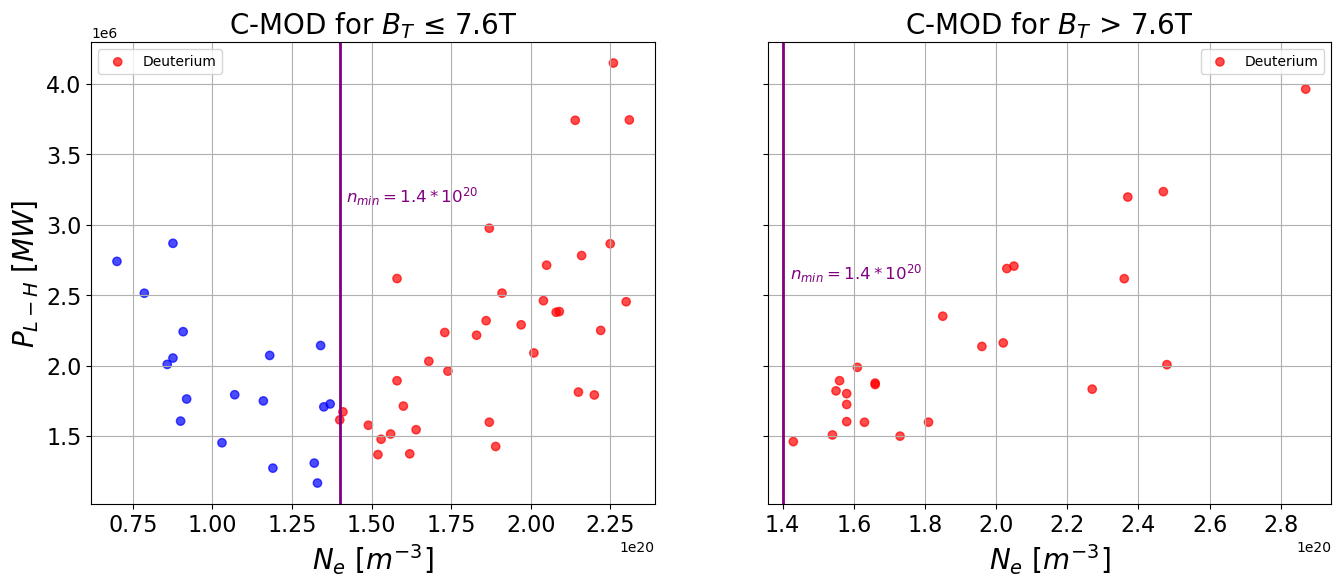

In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 假设 subset1 是你的数据框
colors = subset1['SELEC2024'].map({1: 'red', 0: 'blue'})
x = subset1['NEL']
y = subset1['PLTH']
bt = subset1['BT']

# 分类 BT 值
subset_low = subset1[bt <= 7.6]
subset_high = subset1[bt > 7.6]
print(subset1['BT'])

marker_dict = {
    'Hydrogen': 's',  # 比如类别 A 使用正方形
    'Deuterium': 'o',  # 类别 B 使用圆形
    'Deuterium and tritium': '^',   # 类别 C 使用三角形
    '3He or tritium': 'v',  # 倒三角
    '4He': 'P',  # 五边形
    'Nitrogen': '*',  # 星形
}
# 创建一行两列的子图布局
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)  # sharey=True 使得两个子图共享y轴的刻度

# BT <= 7.6，使用圆形 ('o')
#axs[0].scatter(subset_low['NEL'], subset_low['PLTH'], marker='o', c=subset_low['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7)
for cat, marker in marker_dict.items():
    subset = subset_low[subset_low['Category'] == cat]
    if subset.empty:
        continue  # 如果当前类别无数据，则跳过
    axs[0].scatter(subset_low['NEL'], subset_low['PLTH'],
                   marker=marker,
                   c=subset_low['SELEC2024'].map({1: 'red', 0: 'blue'}),
                   alpha=0.7,
                   label=cat)  # 可选：添加图例标签

# 如果需要显示图例
axs[0].legend()
axs[0].set_title('C-MOD for $B_T$ ≤ 7.6T', fontsize=20)
axs[0].set_xlabel('$N_e$ $[m^{-3}]$', fontsize=20)
axs[0].set_ylabel("$P_{L-H}$ $[MW]$", fontsize=20)
axs[0].grid(True)
axs[0].tick_params(axis='both', labelsize=16)
axs[0].axvline(x=1.4e20, color='purple', linewidth=2)
ymin, ymax = axs[0].get_ylim()
y_center = (ymax - ymin) / 1.5 + ymin
axs[0].text(1.42e20, y_center, '$n_{min}=1.4*10^{20}$', color='purple', fontsize=12, verticalalignment='center')

# 在垂直线右侧添加文本 "n=20"
# 这里 x 坐标取 1.42，稍微偏右于 1.4，verticalalignment 设置为居中
# BT > 7.6，使用方形 ('s')
#axs[1].scatter(subset_high['NEL'], subset_high['PLTH'], marker='s', c=subset_high['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7)
for cat, marker in marker_dict.items():
    subset = subset_high[subset_high['Category'] == cat]
    if subset.empty:
        continue  # 如果当前类别无数据，则跳过
    axs[1].scatter(subset_high['NEL'], subset_high['PLTH'],
                   marker=marker,
                   c=subset_high['SELEC2024'].map({1: 'red', 0: 'blue'}),
                   alpha=0.7,
                   label=cat)  # 可选：添加图例标签
axs[1].legend()
axs[1].set_title('C-MOD for $B_T$ > 7.6T', fontsize=20)
axs[1].set_xlabel("$N_e$ $[m^{-3}]$", fontsize=20)
axs[1].grid(True)
axs[1].tick_params(axis='both', labelsize=16)
axs[1].axvline(x=1.4e20, color='purple', linewidth=2)
# 获取当前 y 轴范围，并计算中间位置
ymin, ymax = axs[1].get_ylim()
y_center = (ymax - ymin) / 2 + ymin

# 在垂直线右侧添加文本 "n=20"
# 这里 x 坐标取 1.42，稍微偏右于 1.4，verticalalignment 设置为居中
axs[1].text(1.42e20, y_center, '$n_{min}=1.4*10^{20}$', color='purple', fontsize=12, verticalalignment='center')

plt.show()
# 假设 fig 是你创建的 Figure 对象
fig.savefig("CMOD_n_min.png", dpi=300, bbox_inches='tight')


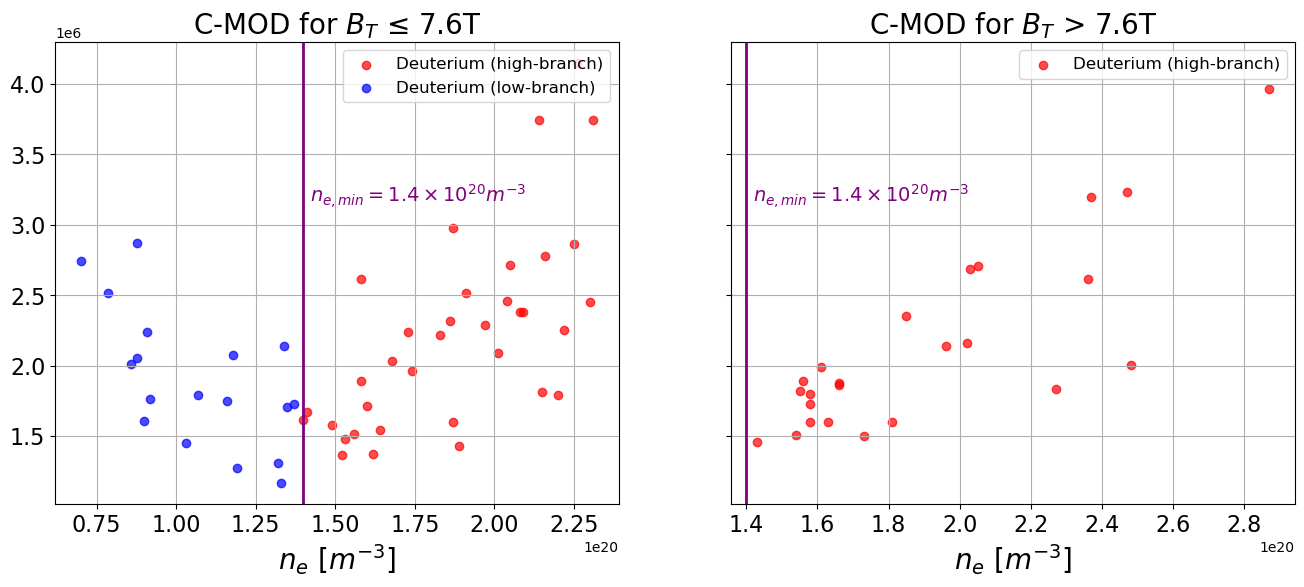

In [129]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 假设 subset1 是你的数据框
colors_map = {1: ('red', 'high-branch'), 0: ('blue', 'low-branch')}
x = subset1['NEL']
y = subset1['PLTH']
bt = subset1['BT']

# 分类 BT 值
subset_low = subset1[bt <= 7.6]
subset_high = subset1[bt > 7.6]

# 定义不同类别对应的 marker
marker_dict = {
    'Hydrogen': 's',
    'Deuterium': 'o',
    'Deuterium and tritium': '^',
    '3He or tritium': 'v',
    '4He': 'P',
    'Nitrogen': '*',
}

fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, subset, title in zip(axs, [subset_low, subset_high], 
                             ['C-MOD for $B_T$ ≤ 7.6T', 'C-MOD for $B_T$ > 7.6T']):
    for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset[(subset['Category'] == cat) & (subset['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                ax.scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})")  # 在图例中显示类别和分支类型

    ax.legend(fontsize=12)  # 调整图例字号
    ax.set_title(title, fontsize=20)
    ax.set_xlabel('$n_e$ $[m^{-3}]$', fontsize=20)
    ax.grid(True)
    ax.tick_params(axis='both', labelsize=16)
    ax.axvline(x=1.4e20, color='purple', linewidth=2)
    
    ymin, ymax = ax.get_ylim()
    y_center = (ymax - ymin) / 1.5 + ymin
    ax.text(1.42e20, y_center, '$n_{e,min}=1.4 \\times 10^{20}m^{-3}$', 
            color='purple', fontsize=14, verticalalignment='center')

plt.show()
fig.savefig("CMOD_n_min.png", dpi=300, bbox_inches='tight')


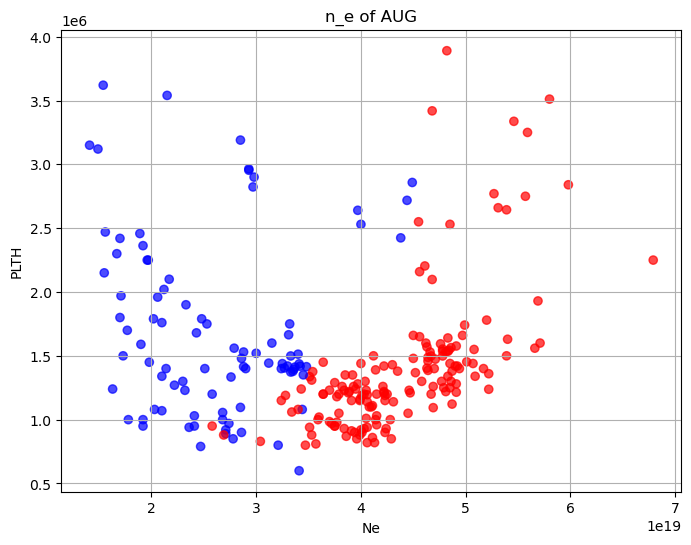

In [56]:
colors = subset2['SELEC2024'].map({1: 'red', 0: 'blue'})
x = subset2['NEL'] 
y = subset2['PLTH'] 

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color=colors, alpha=0.7) 
plt.title('n_e of AUG')
plt.xlabel('Ne')
plt.ylabel('PLTH')
plt.grid(True)
plt.show()

<>:44: SyntaxWarning: invalid escape sequence '\ '
<>:66: SyntaxWarning: invalid escape sequence '\ '
<>:91: SyntaxWarning: invalid escape sequence '\ '
<>:118: SyntaxWarning: invalid escape sequence '\ '
<>:44: SyntaxWarning: invalid escape sequence '\ '
<>:66: SyntaxWarning: invalid escape sequence '\ '
<>:91: SyntaxWarning: invalid escape sequence '\ '
<>:118: SyntaxWarning: invalid escape sequence '\ '
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_24184/3017389073.py:44: SyntaxWarning: invalid escape sequence '\ '
  axs[0,0].text(2.5e19, y_center, '$\ n_{e,min}=2.5*10^{19}m^{-3}$', color='purple', fontsize=16, verticalalignment='center')
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_24184/3017389073.py:66: SyntaxWarning: invalid escape sequence '\ '
  axs[0,1].text(3.0e19, y_center, '$\ n_{e,min}=3.0*10^{19}m^{-3}$', color='purple', fontsize=16, verticalalignment='center')
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_24184/3017389073.py:91: S

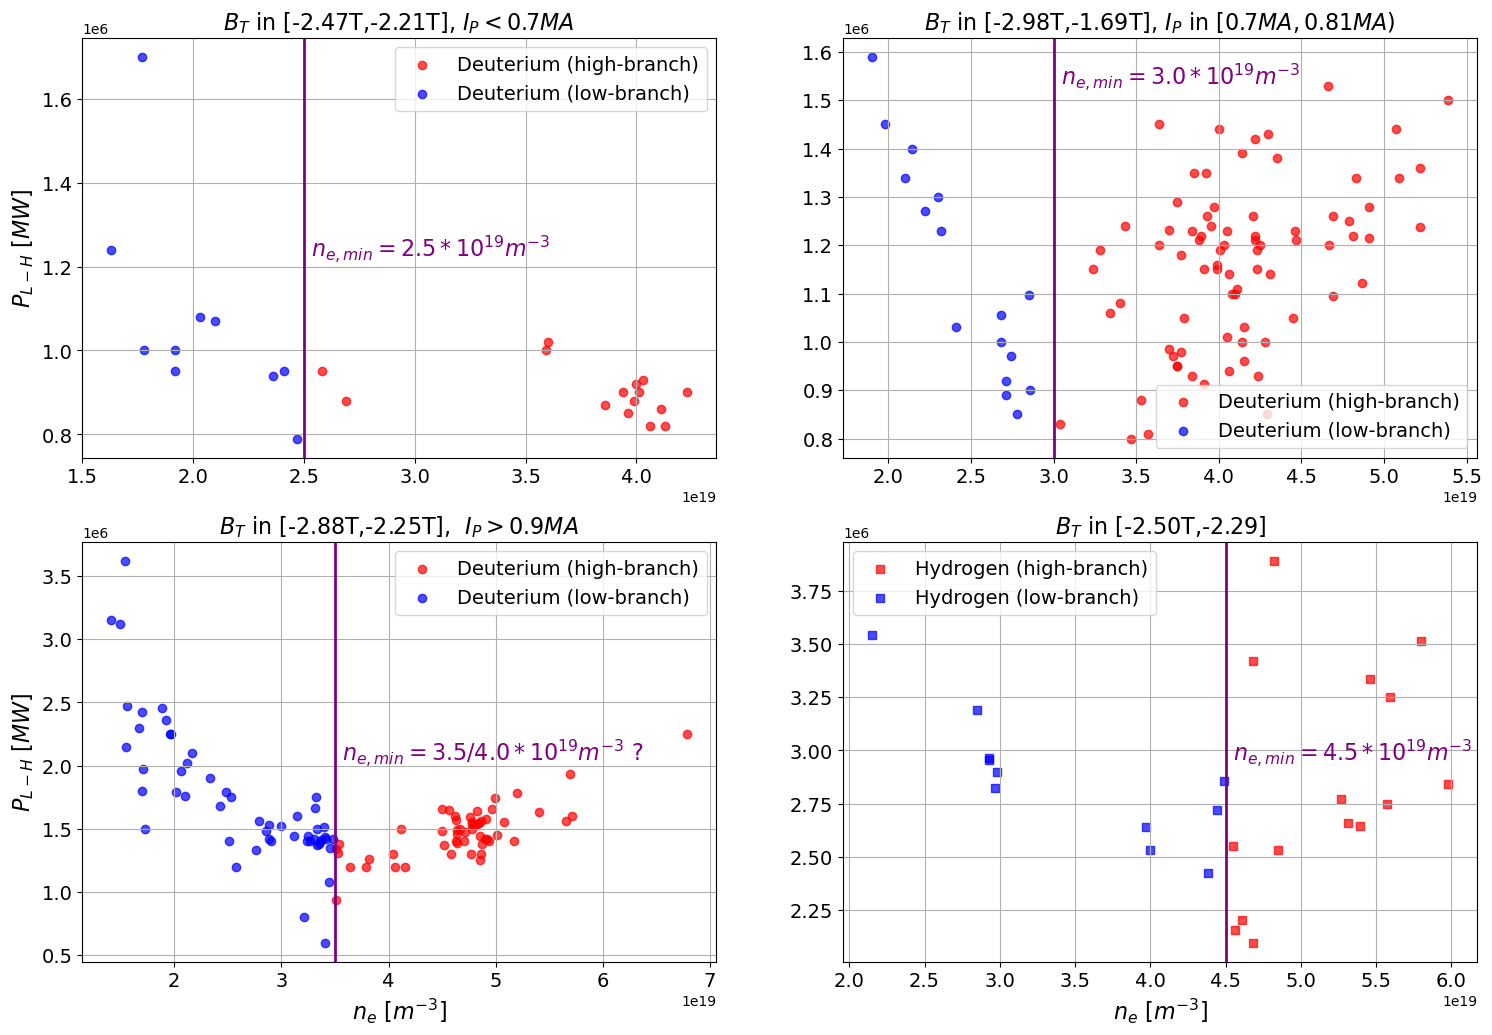

In [128]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 假设 subset1 是你的数据框
colors_map = {1: ('red', 'high-branch'), 0: ('blue', 'low-branch')}
colors = subset2['SELEC2024'].map({1: 'red', 0: 'blue'})
x = subset2['NEL']
y = subset2['PLTH']
ip = subset2['IP']

# 分类 BT 值
subset2_low = subset2[(ip < 0.7) & (subset2['Category'] != 'Hydrogen')]
subset2_mid = subset2[(ip >= 0.7) & (ip < 0.81)& (subset2['Category'] != 'Hydrogen')]

subset2_high = subset2[(ip >= 0.9) & (subset2['Category'] != 'Hydrogen')]

subset2_hydro = subset2[subset2['Category'] == 'Hydrogen']

# 创建一行3列的子图布局
fig, axs = plt.subplots(2, 2, figsize=(18, 12))  # sharey=True 使得两个子图共享y轴的刻度


#axs[0,0].scatter(subset2_low['NEL'], subset2_low['PLTH'], marker='o', c=subset2_low['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7)
for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_low[(subset2_low['Category'] == cat) & (subset2_low['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[0,0].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})")  # 在图例中显示类别和分支类型

#axs[0,0].set_title('IP < 0.7')
bt_min, bt_max = subset2_low['BT'].min(), subset2_low['BT'].max()
axs[0,0].legend(fontsize=14)
axs[0,0].set_title(f"$B_T$ in [{bt_min:.2f}T,{bt_max:.2f}T]"+', $I_P < 0.7MA$', fontsize=16)
axs[0,0].set_ylabel('$P_{L-H}$ $[MW]$', fontsize=16)
axs[0,0].axvline(x=2.5e19, color='purple', linewidth=2)
axs[0,0].tick_params(axis='both', labelsize=14)
axs[0,0].grid(True)
ymin, ymax = axs[0,0].get_ylim()
y_center = (ymax - ymin) / 2 + ymin
axs[0,0].text(2.5e19, y_center, '$\ n_{e,min}=2.5*10^{19}m^{-3}$', color='purple', fontsize=16, verticalalignment='center')
#print(subset2_low['DIVCON'])

#axs[0,1].scatter(subset2_mid['NEL'], subset2_mid['PLTH'], marker='o', c=subset2_mid['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7)
for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_mid[(subset2_mid['Category'] == cat) & (subset2_mid['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[0,1].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})")  # 在图例中显示类别和分支类型

#axs[0,1].set_title('0.7<= IP < 0.81')
bt_min, bt_max = subset2_mid['BT'].min(), subset2_mid['BT'].max()
axs[0,1].legend(fontsize=14)
axs[0,1].set_title(f"$B_T$ in [{bt_min:.2f}T,{bt_max:.2f}T]"+', $I_P$ in $[0.7MA,0.81MA)$', fontsize=16)
axs[0,1].axvline(x=3.0e19, color='purple', linewidth=2)
axs[0,1].tick_params(axis='both', labelsize=14)
axs[0,1].grid(True)
ymin, ymax = axs[0,1].get_ylim()
y_center = (ymax - ymin) / 1.1 + ymin
axs[0,1].text(3.0e19, y_center, '$\ n_{e,min}=3.0*10^{19}m^{-3}$', color='purple', fontsize=16, verticalalignment='center')
#print(subset2_mid['DIVCON'])
#axs[1,0].scatter(subset2_high['NEL'], subset2_high['PLTH'], marker='o', c=subset2_high['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7)

for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_high[(subset2_high['Category'] == cat) & (subset2_high['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[1,0].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})")  # 在图例中显示类别和分支类型

#print(subset2_high['DIVCON'])
#axs[1,0].set_title('IP > 0.9')
bt_min, bt_max = subset2_high['BT'].min(), subset2_high['BT'].max()
axs[1,0].legend(fontsize=14)
axs[1,0].set_title(f"$B_T$ in [{bt_min:.2f}T,{bt_max:.2f}T]"+',  $I_P>0.9MA$', fontsize=16)
axs[1,0].set_xlabel('$n_e$ $[m^{-3}]$', fontsize=16)
axs[1,0].set_ylabel('$P_{L-H}$ $[MW]$', fontsize=16)
axs[1,0].axvline(x=3.5e19, color='purple', linewidth=2)
axs[1,0].tick_params(axis='both', labelsize=14)
axs[1,0].grid(True)
ymin, ymax = axs[1,0].get_ylim()
y_center = (ymax - ymin) / 2 + ymin
axs[1,0].text(3.5e19, y_center, '$\ n_{e,min}=3.5/4.0*10^{19}m^{-3}\ ?$', color='purple', fontsize=16, verticalalignment='center')

#axs[1,1].scatter(subset2_hydro['NEL'], subset2_hydro['PLTH'], marker='o', c=subset2_hydro['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7)

for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_hydro[(subset2_hydro['Category'] == cat) & (subset2_hydro['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[1,1].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})")  # 在图例中显示类别和分支类型

#axs[1,1].set_title('hydrogen')
axs[1,1].legend( fontsize=14)
bt_min, bt_max = subset2_hydro['BT'].min(), subset2_hydro['BT'].max()
axs[1,1].set_title(f"$B_T$ in [{bt_min:.2f}T,{bt_max:.2f}]", fontsize=16)
axs[1,1].set_xlabel('$n_e$ $[m^{-3}]$', fontsize=16)
axs[1,1].grid(True)
axs[1,1].tick_params(axis='both', labelsize=14)
axs[1,1].axvline(x=4.5e19, color='purple', linewidth=2)
ymin, ymax = axs[1,1].get_ylim()
#print(subset2_hydro['DIVCON'])
y_center = (ymax - ymin) / 2 + ymin
# 设置全局图例
handles, labels = axs[0,0].get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper right', title='Markers & Colors')
axs[1,1].text(4.5e19, y_center, '$\ n_{e,min}=4.5*10^{19}m^{-3}$', color='purple', fontsize=16, verticalalignment='center')

plt.show()
# 假设 fig 是你创建的 Figure 对象
fig.savefig("AUG_n_min.png", dpi=300, bbox_inches='tight')

In [33]:
subset2_high

,TOK,SHOT,TIME,PHASE,PGASA,RGEO,AMIN,KAPPA,SPLASMA,CONFIG,...,PL,PLTH,PFLOSS,PRADCORE,DIVCON,FRACNMIN,LHTIME,AUXHEAT,SELEC2024,Category


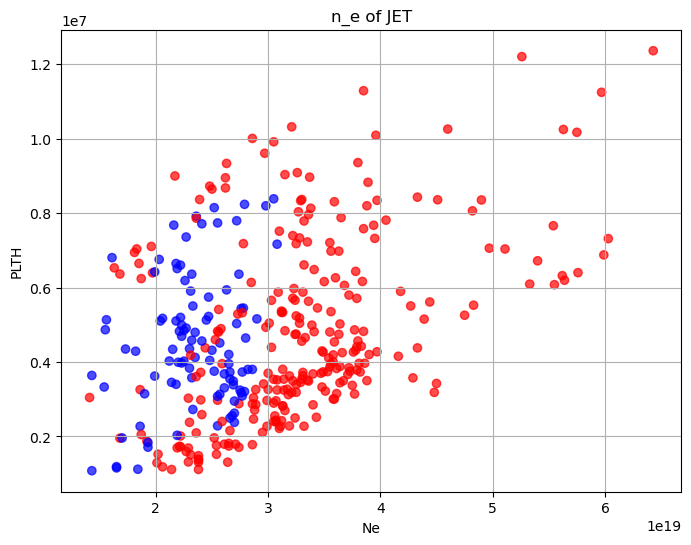

In [68]:
colors = subset3['SELEC2024'].map({1: 'red', 0: 'blue'})
x = subset3['NEL'] 
y = subset3['PLTH'] 

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color=colors, alpha=0.7) 
plt.title('n_e of JET')
plt.xlabel('Ne')
plt.ylabel('PLTH')
plt.grid(True)
plt.show()

<>:49: SyntaxWarning: invalid escape sequence '\ '
<>:74: SyntaxWarning: invalid escape sequence '\ '
<>:99: SyntaxWarning: invalid escape sequence '\ '
<>:125: SyntaxWarning: invalid escape sequence '\ '
<>:153: SyntaxWarning: invalid escape sequence '\ '
<>:176: SyntaxWarning: invalid escape sequence '\ '
<>:49: SyntaxWarning: invalid escape sequence '\ '
<>:74: SyntaxWarning: invalid escape sequence '\ '
<>:99: SyntaxWarning: invalid escape sequence '\ '
<>:125: SyntaxWarning: invalid escape sequence '\ '
<>:153: SyntaxWarning: invalid escape sequence '\ '
<>:176: SyntaxWarning: invalid escape sequence '\ '
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_24184/2700354178.py:49: SyntaxWarning: invalid escape sequence '\ '
  axs[0,0].text(1.7e19, y_center, '$\ n_{e,min}=1.7*10^{19}m^{-3} ?$', color='purple', fontsize=18, verticalalignment='center')
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_24184/2700354178.py:74: SyntaxWarning: invalid escape sequence '\ '


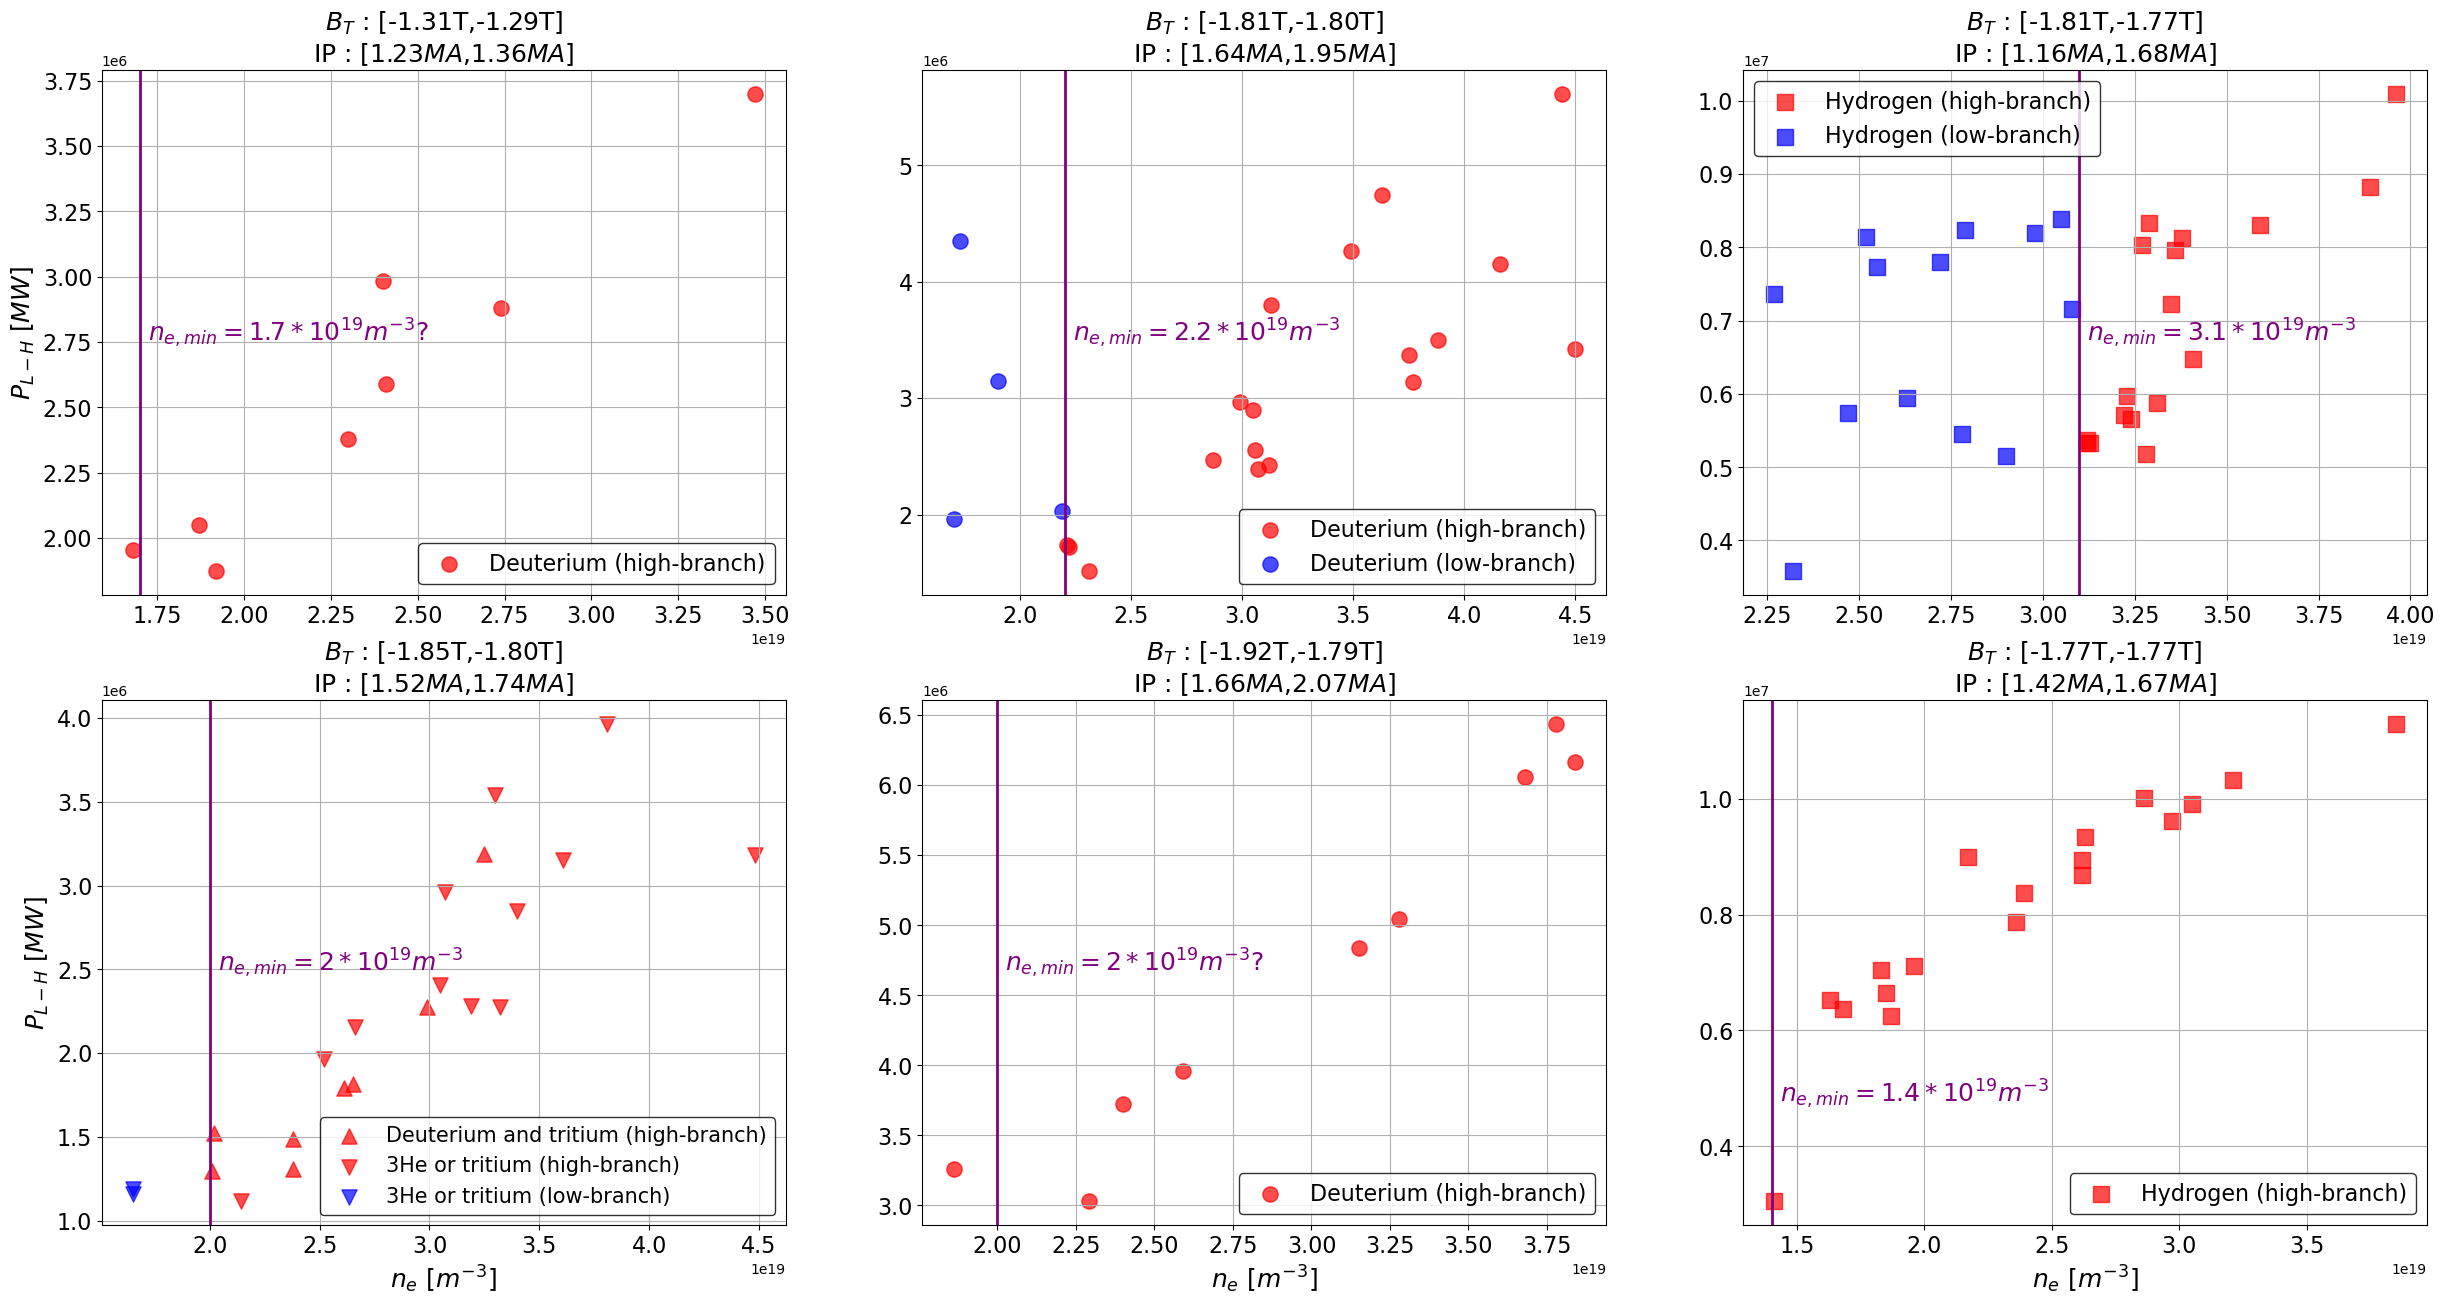

In [126]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 假设 subset1 是你的数据框
colors = subset3['SELEC2024'].map({1: 'red', 0: 'blue'})
colors_map = {1: ('red', 'high-branch'), 0: ('blue', 'low-branch')}
x = subset3['NEL']
y = subset3['PLTH']
bt = subset3['BT'].abs()
ip= subset3['IP']

# 分类 BT 值
subset2_1 = subset3[(bt < 1.5) & (bt >=1.1)& (subset3['Category'] == 'Deuterium')& ((subset3['DIVCON'] == 'VT')|(subset3['DIVCON'] == 'CORNER'))]
subset2_2 = subset3[(bt < 2.0) & (bt >=1.5)& (subset3['Category'] == 'Deuterium')& (subset3['DIVCON'] == 'V5')]
subset2_3 = subset3[(bt < 2.0) & (bt >=1.5)& (subset3['Category'] == 'Hydrogen')& (subset3['DIVCON'] == 'V5')]
subset2_4 = subset3[(bt < 2.0) & (bt >=1.5)& ((subset3['Category'] == 'Deuterium and tritium')|(subset3['Category'] == '3He or tritium'))& (subset3['DIVCON'] == 'V5')]
subset2_5 = subset3[(bt < 2.0) & (bt >=1.5)& (subset3['Category'] == 'Deuterium')& (subset3['DIVCON'] == 'CORNER')]
subset2_6 = subset3[(bt < 2.0) & (bt >=1.5)& (subset3['Category'] == 'Hydrogen')& (subset3['DIVCON'] == 'CORNER')]

s1=120
# 创建一行3列的子图布局
fig, axs = plt.subplots(2, 3, figsize=(30, 15))  # sharey=True 使得两个子图共享y轴的刻度


#axs[0,0].scatter(subset2_1['NEL'], subset2_1['PLTH'], marker='o', c=subset2_1['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7,s=s1)

for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_1[(subset2_1['Category'] == cat) & (subset2_1['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[0,0].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})",s=s1)  # 在图例中显示类别和分支类型
#axs[0,0].set_title('IP < 0.7')
bt_min, bt_max = subset2_1['BT'].min(), subset2_1['BT'].max()
ip_min, ip_max = subset2_1['IP'].min(), subset2_1['IP'].max()
axs[0,0].set_title(f"$B_T$ : [{bt_min:.2f}T,{bt_max:.2f}T]"+f"\nIP : [{ip_min:.2f}$MA$,{ip_max:.2f}$MA$]", fontsize=18)
axs[0,0].legend(fontsize=16, edgecolor='black')
axs[0,0].tick_params(axis='both', labelsize=16)
#axs[0,0].set_xlabel('$N_e$ $[m^{-3}]$')
axs[0,0].set_ylabel('$P_{L-H}$ $[MW]$', fontsize=18)
axs[0,0].grid(True)
axs[0,0].axvline(x=1.7e19, color='purple', linewidth=2)
ymin, ymax = axs[0,0].get_ylim()
axs[0,0].tick_params(axis='both', labelsize=16)
y_center = (ymax - ymin) / 2 + ymin
axs[0,0].text(1.7e19, y_center, '$\ n_{e,min}=1.7*10^{19}m^{-3} ?$', color='purple', fontsize=18, verticalalignment='center')


#axs[0,1].scatter(subset2_2['NEL'], subset2_2['PLTH'], marker='o', c=subset2_2['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7,s=s1)

for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_2[(subset2_2['Category'] == cat) & (subset2_2['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[0,1].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})",s=s1)  # 在图例中显示类别和分支类型
#axs[0,1].set_title('0.7<= IP < 0.81')
axs[0,1].legend(fontsize=16, edgecolor='black')
bt_min, bt_max = subset2_2['BT'].min(), subset2_2['BT'].max()
ip_min, ip_max = subset2_2['IP'].min(), subset2_2['IP'].max()
axs[0,1].set_title(f"$B_T$ : [{bt_min:.2f}T,{bt_max:.2f}T]"+f"\nIP : [{ip_min:.2f}$MA$,{ip_max:.2f}$MA$]", fontsize=18)
#axs[0,1].set_xlabel('$N_e$ $[m^{-3}]$')
axs[0,1].tick_params(axis='both', labelsize=16)
axs[0,1].grid(True)
axs[0,1].axvline(x=2.2e19, color='purple', linewidth=2)
ymin, ymax = axs[0,1].get_ylim()
axs[0,1].tick_params(axis='both', labelsize=16)
y_center = (ymax - ymin) / 2 + ymin
axs[0,1].text(2.2e19, y_center, '$\ n_{e,min}=2.2*10^{19}m^{-3}$', color='purple', fontsize=18, verticalalignment='center')

#axs[0,2].scatter(subset2_3['NEL'], subset2_3['PLTH'], marker='o', c=subset2_3['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7,s=s1)
#axs[1,0].set_title('IP > 0.9')

for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_3[(subset2_3['Category'] == cat) & (subset2_3['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[0,2].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})",s=s1)  # 在图例中显示类别和分支类型
#axs[0,1].set_title('0.7<= IP < 0.81')
axs[0,2].legend(fontsize=16, edgecolor='black')
bt_min, bt_max = subset2_3['BT'].min(), subset2_3['BT'].max()
ip_min, ip_max = subset2_3['IP'].min(), subset2_3['IP'].max()
axs[0,2].set_title(f"$B_T$ : [{bt_min:.2f}T,{bt_max:.2f}T]"+f"\nIP : [{ip_min:.2f}$MA$,{ip_max:.2f}$MA$]", fontsize=18)
#axs[0,2].set_xlabel('$N_e$ $[m^{-3}]$')
axs[0,2].tick_params(axis='both', labelsize=16)
axs[0,2].grid(True)
axs[0,2].axvline(x=3.1e19, color='purple', linewidth=2)
ymin, ymax = axs[0,2].get_ylim()
axs[0,2].tick_params(axis='both', labelsize=16)
y_center = (ymax - ymin) / 2 + ymin
axs[0,2].text(3.1e19, y_center, '$\ n_{e,min}=3.1*10^{19}m^{-3}$', color='purple', fontsize=18, verticalalignment='center')

#axs[1,0].scatter(subset2_4['NEL'], subset2_4['PLTH'], marker='o', c=subset2_4['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7,s=s1)

for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_4[(subset2_4['Category'] == cat) & (subset2_4['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[1,0].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})",s=s1)  # 在图例中显示类别和分支类型
#axs[0,1].set_title('0.7<= IP < 0.81')
axs[1,0].legend(fontsize=15,loc='lower right', edgecolor='black')
#axs[1,1].set_title('hydrogen')
bt_min, bt_max = subset2_4['BT'].min(), subset2_4['BT'].max()
ip_min, ip_max = subset2_4['IP'].min(), subset2_4['IP'].max()
axs[1,0].set_title(f"$B_T$ : [{bt_min:.2f}T,{bt_max:.2f}T]"+f"\nIP : [{ip_min:.2f}$MA$,{ip_max:.2f}$MA$]", fontsize=18)
axs[1,0].set_xlabel('$n_e$ $[m^{-3}]$', fontsize=18)
axs[1,0].tick_params(axis='both', labelsize=16)
axs[1,0].set_ylabel('$P_{L-H}$ $[MW]$', fontsize=18)
axs[1,0].grid(True)
axs[1,0].axvline(x=2e19, color='purple', linewidth=2)
ymin, ymax = axs[1,0].get_ylim()
axs[1,0].tick_params(axis='both', labelsize=16)
y_center = (ymax - ymin) / 2 + ymin
axs[1,0].text(2e19, y_center, '$\ n_{e,min}=2*10^{19}m^{-3}$', color='purple', fontsize=18, verticalalignment='center')





#axs[1,1].scatter(subset2_5['NEL'], subset2_5['PLTH'], marker='o', c=subset2_5['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7,s=s1)

for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_5[(subset2_5['Category'] == cat) & (subset2_5['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[1,1].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})",s=s1)  # 在图例中显示类别和分支类型
axs[1,1].legend(fontsize=16, edgecolor='black')
#axs[1,0].set_title('IP > 0.9')
bt_min, bt_max = subset2_5['BT'].min(), subset2_5['BT'].max()
ip_min, ip_max = subset2_5['IP'].min(), subset2_5['IP'].max()
axs[1,1].set_title(f"$B_T$ : [{bt_min:.2f}T,{bt_max:.2f}T]"+f"\nIP : [{ip_min:.2f}$MA$,{ip_max:.2f}$MA$]", fontsize=18)
axs[1,1].set_xlabel('$n_e$ $[m^{-3}]$', fontsize=18)
axs[1,1].tick_params(axis='both', labelsize=16)
axs[1,1].grid(True)
axs[1,1].axvline(x=2e19, color='purple', linewidth=2)
ymin, ymax = axs[1,1].get_ylim()
axs[1,1].tick_params(axis='both', labelsize=16)
y_center = (ymax - ymin) / 2 + ymin
axs[1,1].text(2e19, y_center, '$\ n_{e,min}=2*10^{19}m^{-3} ?$', color='purple', fontsize=18, verticalalignment='center')

#axs[1,2].scatter(subset2_6['NEL'], subset2_6['PLTH'], marker='o', c=subset2_6['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7,s=s1)

for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_6[(subset2_6['Category'] == cat) & (subset2_6['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[1,2].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})",s=s1)  # 在图例中显示类别和分支类型
axs[1,2].legend( fontsize=16, edgecolor='black')
#axs[2,1].set_title('hydrogen')
bt_min, bt_max = subset2_6['BT'].min(), subset2_6['BT'].max()
ip_min, ip_max = subset2_6['IP'].min(), subset2_6['IP'].max()
axs[1,2].set_title(f"$B_T$ : [{bt_min:.2f}T,{bt_max:.2f}T]"+f"\nIP : [{ip_min:.2f}$MA$,{ip_max:.2f}$MA$]", fontsize=18)
axs[1,2].set_xlabel('$n_e$ $[m^{-3}]$', fontsize=18)
axs[1,2].grid(True)
axs[1,2].axvline(x=1.4e19, color='purple', linewidth=2)
ymin, ymax = axs[1,2].get_ylim()
axs[1,2].tick_params(axis='both', labelsize=16)
y_center = (ymax - ymin) / 4 + ymin
axs[1,2].text(1.4e19, y_center, '$\ n_{e,min}=1.4*10^{19}m^{-3}$', color='purple', fontsize=18, verticalalignment='center')


plt.show()
fig.savefig("JET1_n_min.png", dpi=300, bbox_inches='tight')

<>:49: SyntaxWarning: invalid escape sequence '\ '
<>:73: SyntaxWarning: invalid escape sequence '\ '
<>:96: SyntaxWarning: invalid escape sequence '\ '
<>:121: SyntaxWarning: invalid escape sequence '\ '
<>:149: SyntaxWarning: invalid escape sequence '\ '
<>:49: SyntaxWarning: invalid escape sequence '\ '
<>:73: SyntaxWarning: invalid escape sequence '\ '
<>:96: SyntaxWarning: invalid escape sequence '\ '
<>:121: SyntaxWarning: invalid escape sequence '\ '
<>:149: SyntaxWarning: invalid escape sequence '\ '
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_24184/1364176790.py:49: SyntaxWarning: invalid escape sequence '\ '
  axs[0,0].text(2.85e19, y_center, '$\ n_{e,min}=2.85*10^{19}m^{-3}$', color='purple', fontsize=18, verticalalignment='center')
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_24184/1364176790.py:73: SyntaxWarning: invalid escape sequence '\ '
  axs[0,1].text(2.7e19, y_center, '$\ n_{e,min}=2.7*10^{19}m^{-3}$', color='purple', fontsize=18, vertic

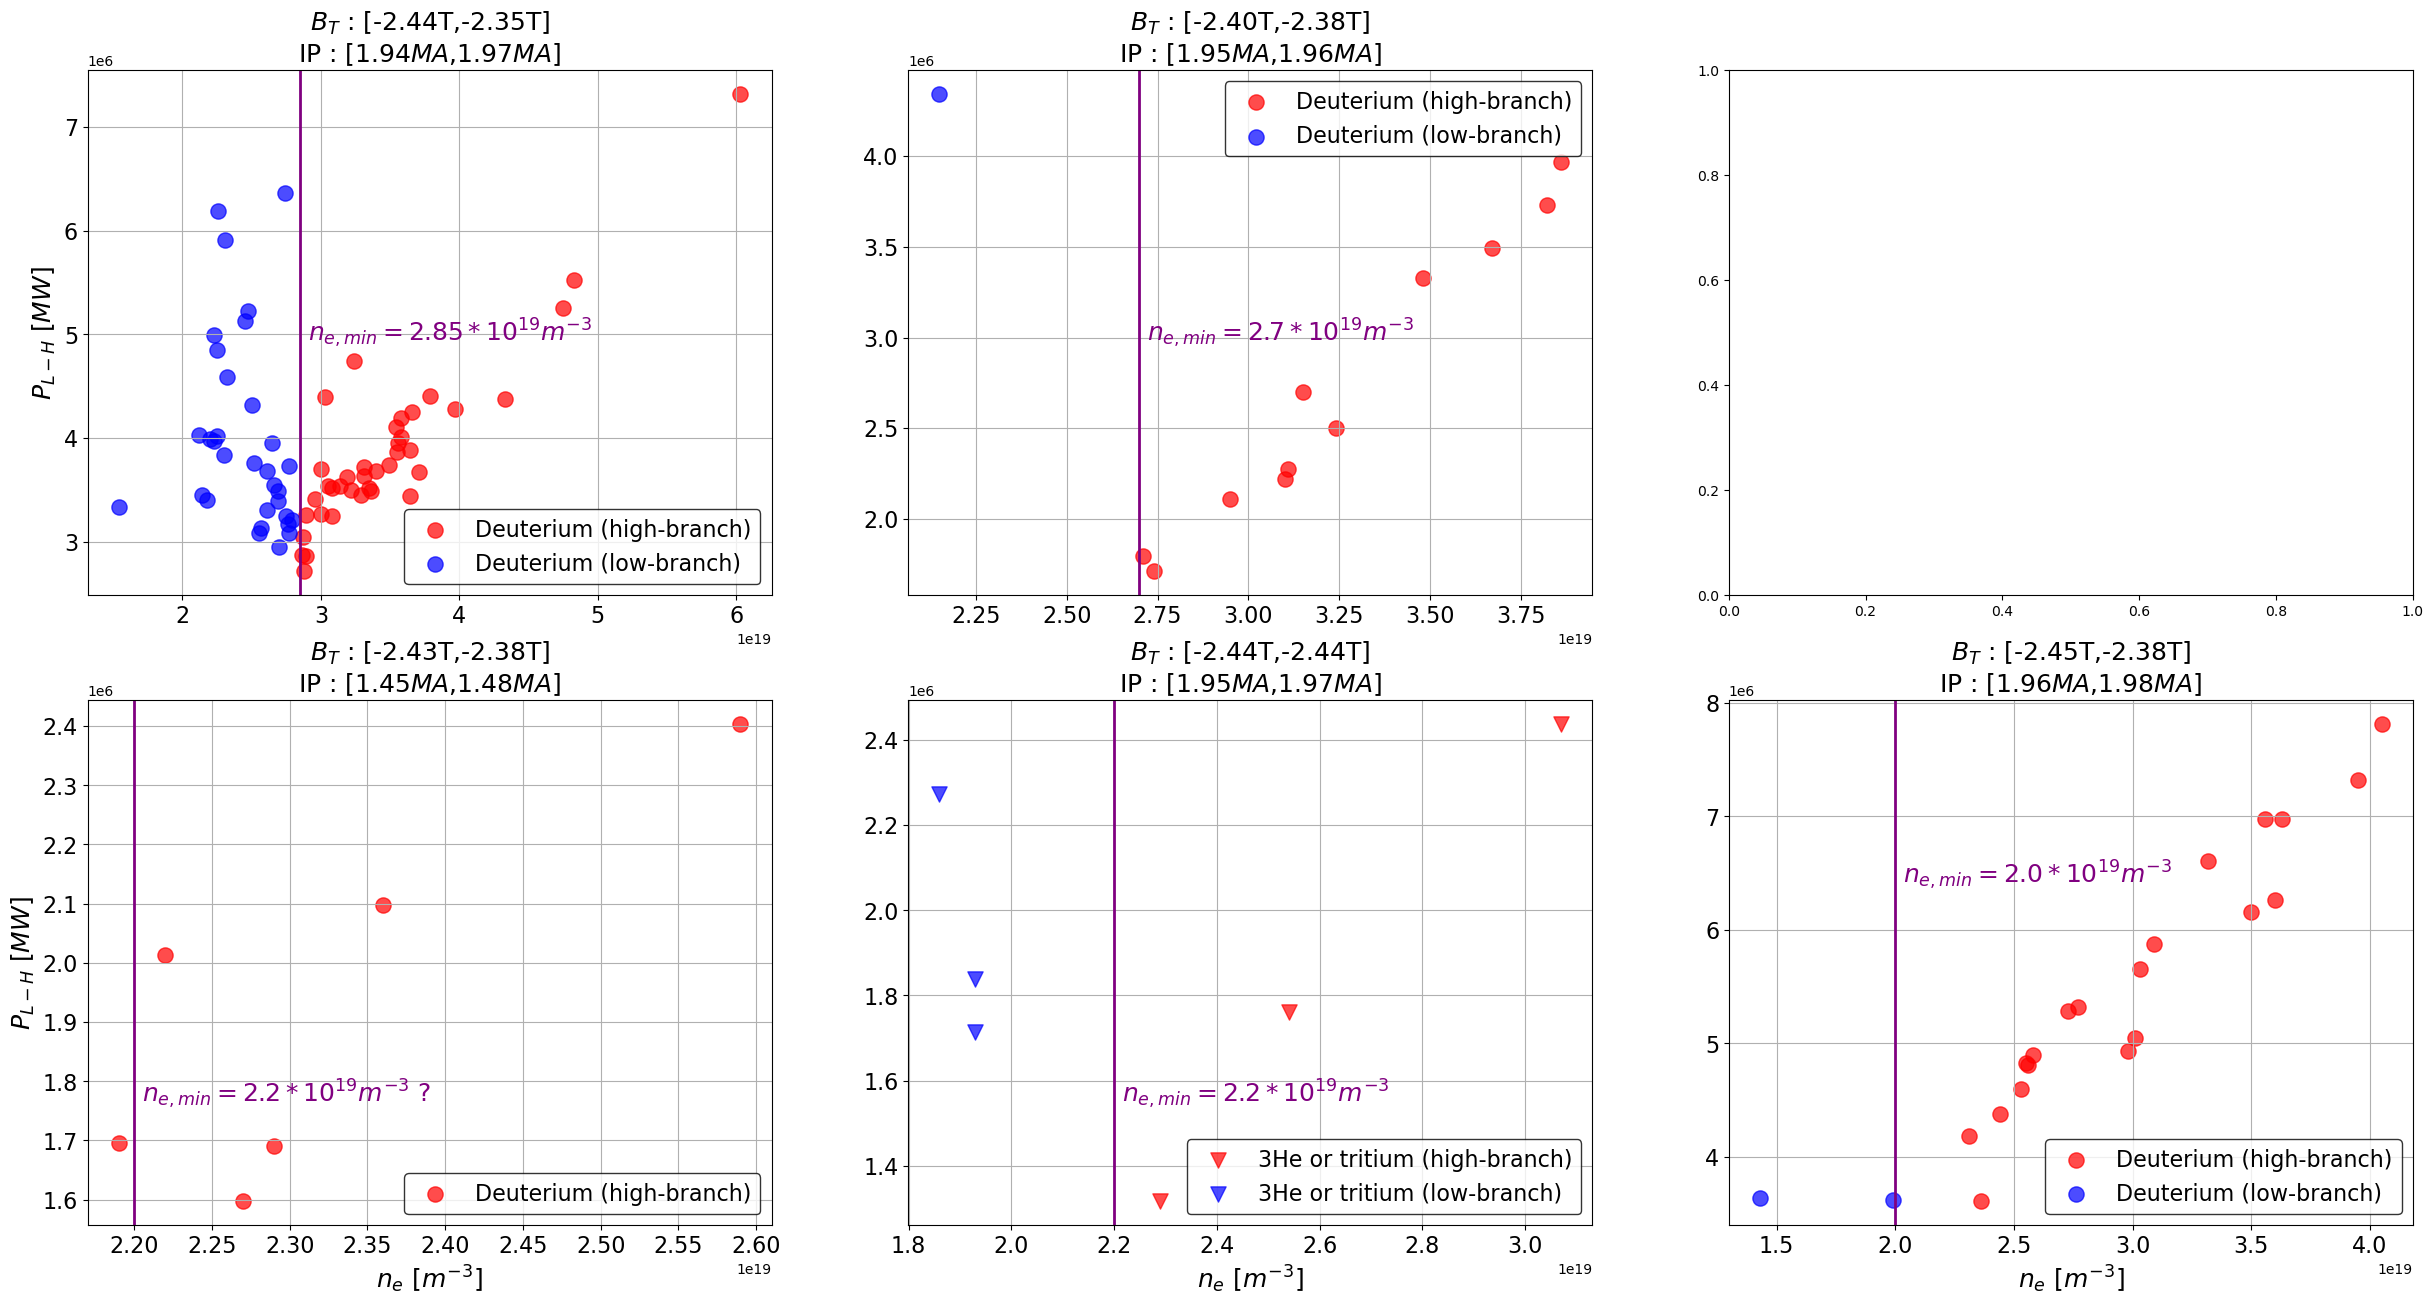

In [127]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 假设 subset1 是你的数据框
colors_map = {1: ('red', 'high-branch'), 0: ('blue', 'low-branch')}
colors = subset3['SELEC2024'].map({1: 'red', 0: 'blue'})
x = subset3['NEL']
y = subset3['PLTH']
bt = subset3['BT'].abs()
ip= subset3['IP']

# 分类 BT 值
subset2_1 = subset3[(ip < 2.3) & (ip >=1.7)&(bt < 2.6) & (bt >=2.0)& (subset3['Category'] == 'Deuterium')& (subset3['DIVCON'] == 'V5')]
subset2_2 = subset3[(ip < 2.3) & (ip >=1.7)&(bt < 2.6) & (bt >=2.0)& (subset3['Category'] == 'Deuterium')& (subset3['DIVCON'] == 'V5L')]
subset2_3 = subset3[(ip < 2.3) & (ip >=1.7)&(bt < 2.6) & (bt >=2.0)& (subset3['Category'] == 'Deuterium')& ((subset3['DIVCON'] == 'VT')|(subset3['DIVCON'] == 'CORNER'))]
subset2_4 = subset3[(ip < 1.7) & (ip >=1.2)&(bt < 2.6) & (bt >=2.0)& (subset3['Category'] == 'Deuterium')& (subset3['DIVCON'] == 'V5')]
subset2_5 = subset3[(ip < 2.3) & (ip >=1.7)&(bt < 2.6) & (bt >=2.0)& (subset3['Category'] == '3He or tritium')& (subset3['DIVCON'] == 'V5')]
#subset2_6 = subset3[(ip < 1.8) & (ip >=1.6)&(bt < 2.0) & (bt >=1.5)& (subset3['Category'] == 'Hydrogen')& (subset3['DIVCON'] == 'CORNER')]


# 创建一行3列的子图布局
fig, axs = plt.subplots(2, 3, figsize=(30, 15))  # sharey=True 使得两个子图共享y轴的刻度


#axs[0,0].scatter(subset2_1['NEL'], subset2_1['PLTH'], marker='o', c=subset2_1['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7)


for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_1[(subset2_1['Category'] == cat) & (subset2_1['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[0,0].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})",s=s1)  # 在图例中显示类别和分支类型
axs[0,0].legend( fontsize=16, edgecolor='black')
#axs[0,0].set_title('IP < 0.7')
bt_min, bt_max = subset2_1['BT'].min(), subset2_1['BT'].max()
ip_min, ip_max = subset2_1['IP'].min(), subset2_1['IP'].max()
axs[0,0].set_title(f"$B_T$ : [{bt_min:.2f}T,{bt_max:.2f}T]"+f"\nIP : [{ip_min:.2f}$MA$,{ip_max:.2f}$MA$]", fontsize=18)
axs[0,0].tick_params(axis='both', labelsize=16)
axs[0,0].set_ylabel('$P_{L-H}$ $[MW]$', fontsize=18)
axs[0,0].grid(True)
axs[0,0].axvline(x=2.85e19, color='purple', linewidth=2)
ymin, ymax = axs[0,0].get_ylim()
axs[0,0].tick_params(axis='both', labelsize=16)
y_center = (ymax - ymin) / 2 + ymin
axs[0,0].text(2.85e19, y_center, '$\ n_{e,min}=2.85*10^{19}m^{-3}$', color='purple', fontsize=18, verticalalignment='center')


#axs[0,1].scatter(subset2_2['NEL'], subset2_2['PLTH'], marker='o', c=subset2_2['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7)

for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_2[(subset2_2['Category'] == cat) & (subset2_2['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[0,1].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})",s=s1)  # 在图例中显示类别和分支类型
axs[0,1].legend( fontsize=16, edgecolor='black')
#axs[0,1].set_title('0.7<= IP < 0.81')
bt_min, bt_max = subset2_2['BT'].min(), subset2_2['BT'].max()
ip_min, ip_max = subset2_2['IP'].min(), subset2_2['IP'].max()
axs[0,1].set_title(f"$B_T$ : [{bt_min:.2f}T,{bt_max:.2f}T]"+f"\nIP : [{ip_min:.2f}$MA$,{ip_max:.2f}$MA$]", fontsize=18)

axs[0,1].grid(True)
axs[0,1].axvline(x=2.7e19, color='purple', linewidth=2)
ymin, ymax = axs[0,1].get_ylim()
axs[0,1].tick_params(axis='both', labelsize=16)
y_center = (ymax - ymin) / 2 + ymin
axs[0,1].text(2.7e19, y_center, '$\ n_{e,min}=2.7*10^{19}m^{-3}$', color='purple', fontsize=18, verticalalignment='center')

#axs[0,2].scatter(subset2_3['NEL'], subset2_3['PLTH'], marker='o', c=subset2_3['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7)

for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_3[(subset2_3['Category'] == cat) & (subset2_3['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[1,2].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})",s=s1)  # 在图例中显示类别和分支类型
axs[1,2].legend( fontsize=16, edgecolor='black')
#axs[1,0].set_title('IP > 0.9')
bt_min, bt_max = subset2_3['BT'].min(), subset2_3['BT'].max()
ip_min, ip_max = subset2_3['IP'].min(), subset2_3['IP'].max()
axs[1,2].set_title(f"\nBT Range: {bt_min:.2f} ~ {bt_max:.2f}"+f"\nIP Range: {ip_min:.2f} ~ {ip_max:.2f}")
axs[1,2].set_xlabel('Ne')
axs[1,2].grid(True)
axs[1,2].axvline(x=2.0e19, color='purple', linewidth=2)
ymin, ymax = axs[1,2].get_ylim()
axs[1,2].tick_params(axis='both', labelsize=16)
y_center = (ymax - ymin) / 1.5 + ymin
axs[1,2].text(2.0e19, y_center, '$\ n_{e,min}=2.0*10^{19}m^{-3}$', color='purple', fontsize=18, verticalalignment='center')
axs[1,2].set_title(f"$B_T$ : [{bt_min:.2f}T,{bt_max:.2f}T]"+f"\nIP : [{ip_min:.2f}$MA$,{ip_max:.2f}$MA$]", fontsize=18)
axs[1,2].set_xlabel('$n_e$ $[m^{-3}]$', fontsize=18)
#axs[1,0].scatter(subset2_4['NEL'], subset2_4['PLTH'], marker='o', c=subset2_4['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7)

for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_4[(subset2_4['Category'] == cat) & (subset2_4['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[1,0].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})",s=s1)  # 在图例中显示类别和分支类型
axs[1,0].legend( fontsize=16, edgecolor='black')
#axs[1,1].set_title('hydrogen')
bt_min, bt_max = subset2_4['BT'].min(), subset2_4['BT'].max()
ip_min, ip_max = subset2_4['IP'].min(), subset2_4['IP'].max()
#axs[1,0].set_title(f"\nBT Range: {bt_min:.2f} ~ {bt_max:.2f}"+f"\nIP Range: {ip_min:.2f} ~ {ip_max:.2f}")
axs[1,0].tick_params(axis='both', labelsize=16)
axs[1,0].set_ylabel('$P_{L-H}$ $[MW]$', fontsize=18)
axs[1,0].grid(True)
axs[1,0].axvline(x=2.2e19, color='purple', linewidth=2)
ymin, ymax = axs[1,0].get_ylim()
axs[1,0].tick_params(axis='both', labelsize=16)
y_center = (ymax - ymin) / 4 + ymin
axs[1,0].text(2.2e19, y_center, '$\ n_{e,min}=2.2*10^{19}m^{-3}$ ?', color='purple', fontsize=18, verticalalignment='center')
axs[1,0].set_title(f"$B_T$ : [{bt_min:.2f}T,{bt_max:.2f}T]"+f"\nIP : [{ip_min:.2f}$MA$,{ip_max:.2f}$MA$]", fontsize=18)
axs[1,0].set_xlabel('$n_e$ $[m^{-3}]$', fontsize=18)




#axs[1,1].scatter(subset2_5['NEL'], subset2_5['PLTH'], marker='o', c=subset2_5['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7)

for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_5[(subset2_5['Category'] == cat) & (subset2_5['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[1,1].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})",s=s1)  # 在图例中显示类别和分支类型
axs[1,1].legend( fontsize=16, edgecolor='black')
#axs[1,0].set_title('IP > 0.9')
bt_min, bt_max = subset2_5['BT'].min(), subset2_5['BT'].max()
ip_min, ip_max = subset2_5['IP'].min(), subset2_5['IP'].max()
axs[1,1].set_title(f"$B_T$ : [{bt_min:.2f}T,{bt_max:.2f}T]"+f"\nIP : [{ip_min:.2f}$MA$,{ip_max:.2f}$MA$]", fontsize=18)
axs[1,1].set_xlabel('$n_e$ $[m^{-3}]$', fontsize=18)
axs[1,1].grid(True)
axs[1,1].axvline(x=2.2e19, color='purple', linewidth=2)
ymin, ymax = axs[1,1].get_ylim()
axs[1,1].tick_params(axis='both', labelsize=16)
y_center = (ymax - ymin) / 4 + ymin
axs[1,1].text(2.2e19, y_center, '$\ n_{e,min}=2.2*10^{19}m^{-3}$', color='purple', fontsize=18, verticalalignment='center')



plt.show()
fig.savefig("JET2_n_min.png", dpi=300, bbox_inches='tight')

<>:46: SyntaxWarning: invalid escape sequence '\ '
<>:70: SyntaxWarning: invalid escape sequence '\ '
<>:95: SyntaxWarning: invalid escape sequence '\ '
<>:121: SyntaxWarning: invalid escape sequence '\ '
<>:148: SyntaxWarning: invalid escape sequence '\ '
<>:46: SyntaxWarning: invalid escape sequence '\ '
<>:70: SyntaxWarning: invalid escape sequence '\ '
<>:95: SyntaxWarning: invalid escape sequence '\ '
<>:121: SyntaxWarning: invalid escape sequence '\ '
<>:148: SyntaxWarning: invalid escape sequence '\ '
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_24184/1370501185.py:46: SyntaxWarning: invalid escape sequence '\ '
  axs[0,0].text(3.2e19, y_center, '$\ n_{e,min}=3.2*10^{19}m^{-3}$', color='purple', fontsize=18, verticalalignment='center')
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_24184/1370501185.py:70: SyntaxWarning: invalid escape sequence '\ '
  axs[0,1].text(2.3e19, y_center, '$\ n_{e,min}=2.3*10^{19}m^{-3}$', color='purple', fontsize=18, vertical

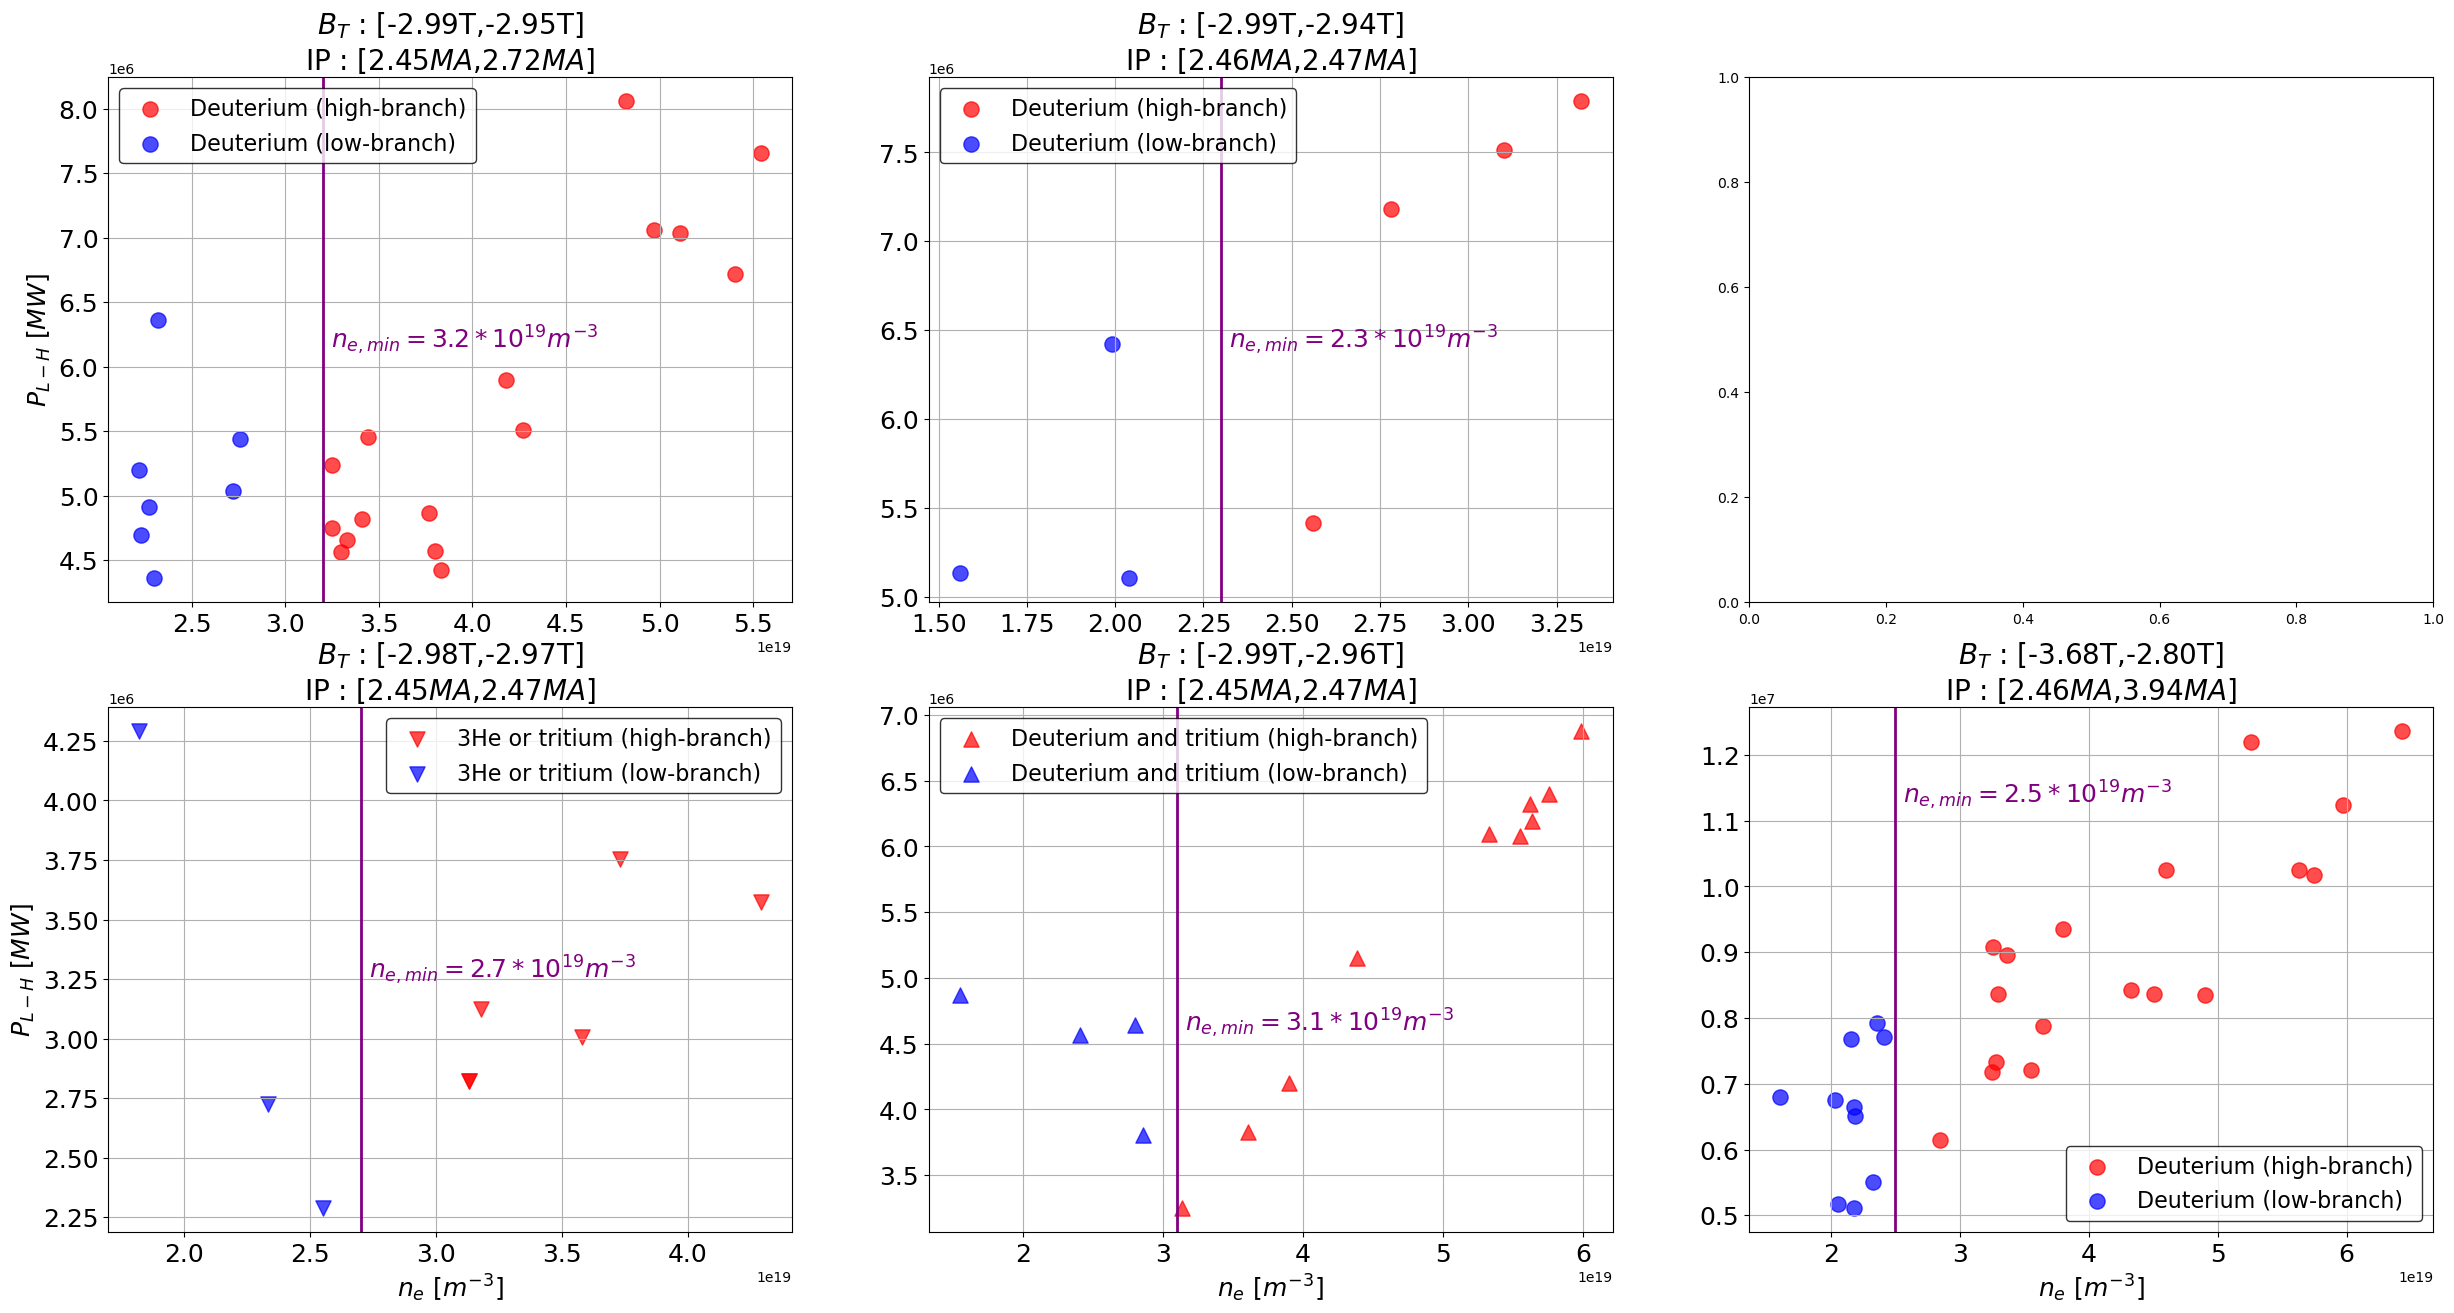

In [122]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 假设 subset1 是你的数据框
colors = subset3['SELEC2024'].map({1: 'red', 0: 'blue'})
x = subset3['NEL']
y = subset3['PLTH']
bt = subset3['BT'].abs()
ip= subset3['IP']

# 分类 BT 值
subset2_1 = subset3[(ip < 2.80) & (ip >=2.4)&(bt < 3.2) & (bt >=2.8)& (subset3['Category'] == 'Deuterium')& ((subset3['DIVCON'] == 'V5')|(subset3['DIVCON'] == 'HT3R'))]
subset2_2 = subset3[(ip < 2.6) & (ip >=2.4)&(bt < 3.2) & (bt >=2.8)& (subset3['Category'] == 'Deuterium')& (subset3['DIVCON'] == 'VT')]
subset2_3 = subset3[(ip < 4.1) & (ip >=2.45)&(bt < 3.75) & (bt >=2.75)& (subset3['Category'] == 'Deuterium')& (subset3['DIVCON'] == 'CORNER')]
subset2_4 = subset3[(ip < 2.6) & (ip >=2.4)&(bt < 3.2) & (bt >=2.8)& (subset3['Category'] == '3He or tritium')& (subset3['DIVCON'] == 'V5')]
subset2_5 = subset3[(ip < 2.6) & (ip >=2.4)&(bt < 3.2) & (bt >=2.8)& (subset3['Category'] == 'Deuterium and tritium')& (subset3['DIVCON'] == 'V5')]
#subset2_6 = subset3[(ip < 1.8) & (ip >=1.6)&(bt < 2.0) & (bt >=1.5)& (subset3['Category'] == 'Hydrogen')& (subset3['DIVCON'] == 'CORNER')]


# 创建一行3列的子图布局
fig, axs = plt.subplots(2, 3, figsize=(30, 15))  # sharey=True 使得两个子图共享y轴的刻度


#axs[0,0].scatter(subset2_1['NEL'], subset2_1['PLTH'], marker='o', c=subset2_1['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7)

for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_1[(subset2_1['Category'] == cat) & (subset2_1['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[0,0].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})",s=s1)  # 在图例中显示类别和分支类型
axs[0,0].legend( fontsize=16, edgecolor='black')
#axs[0,0].set_title('IP < 0.7')
bt_min, bt_max = subset2_1['BT'].min(), subset2_1['BT'].max()
ip_min, ip_max = subset2_1['IP'].min(), subset2_1['IP'].max()
axs[0,0].set_title(f"$B_T$ : [{bt_min:.2f}T,{bt_max:.2f}T]"+f"\nIP : [{ip_min:.2f}$MA$,{ip_max:.2f}$MA$]", fontsize=20)

axs[0,0].set_ylabel('$P_{L-H}$ $[MW]$', fontsize=18)
axs[0,0].axvline(x=3.2e19, color='purple', linewidth=2)
ymin, ymax = axs[0,0].get_ylim()
axs[0,0].tick_params(axis='both', labelsize=18)
y_center = (ymax - ymin) / 2 + ymin
axs[0,0].text(3.2e19, y_center, '$\ n_{e,min}=3.2*10^{19}m^{-3}$', color='purple', fontsize=18, verticalalignment='center')

axs[0,0].grid(True)


#axs[0,1].scatter(subset2_2['NEL'], subset2_2['PLTH'], marker='o', c=subset2_2['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7)

for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_2[(subset2_2['Category'] == cat) & (subset2_2['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[0,1].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})",s=s1)  # 在图例中显示类别和分支类型
axs[0,1].legend( fontsize=16, edgecolor='black')
#axs[0,1].set_title('0.7<= IP < 0.81')
bt_min, bt_max = subset2_2['BT'].min(), subset2_2['BT'].max()
ip_min, ip_max = subset2_2['IP'].min(), subset2_2['IP'].max()
axs[0,1].set_title(f"$B_T$ : [{bt_min:.2f}T,{bt_max:.2f}T]"+f"\nIP : [{ip_min:.2f}$MA$,{ip_max:.2f}$MA$]", fontsize=20)
axs[0,1].axvline(x=2.3e19, color='purple', linewidth=2)
ymin, ymax = axs[0,1].get_ylim()
axs[0,1].tick_params(axis='both', labelsize=18)
y_center = (ymax - ymin) / 2 + ymin
axs[0,1].text(2.3e19, y_center, '$\ n_{e,min}=2.3*10^{19}m^{-3}$', color='purple', fontsize=18, verticalalignment='center')

axs[0,1].grid(True)

#axs[1,0].scatter(subset2_3['NEL'], subset2_3['PLTH'], marker='o', c=subset2_3['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7)

for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_3[(subset2_3['Category'] == cat) & (subset2_3['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[1,2].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})",s=s1)  # 在图例中显示类别和分支类型
axs[1,2].legend( fontsize=16, edgecolor='black')
#axs[1,0].set_title('IP > 0.9')
bt_min, bt_max = subset2_3['BT'].min(), subset2_3['BT'].max()
ip_min, ip_max = subset2_3['IP'].min(), subset2_3['IP'].max()
axs[1,2].set_title(f"$B_T$ : [{bt_min:.2f}T,{bt_max:.2f}T]"+f"\nIP : [{ip_min:.2f}$MA$,{ip_max:.2f}$MA$]", fontsize=20)
axs[1,2].set_xlabel('$n_e$ $[m^{-3}]$', fontsize=18)
axs[1,2].grid(True)
axs[1,2].axvline(x=2.5e19, color='purple', linewidth=2)
ymin, ymax = axs[1,2].get_ylim()
axs[1,2].tick_params(axis='both', labelsize=18)
y_center = (ymax - ymin) / 1.2 + ymin
axs[1,2].text(2.5e19, y_center, '$\ n_{e,min}=2.5*10^{19}m^{-3}$', color='purple', fontsize=18, verticalalignment='center')


#axs[1,1].scatter(subset2_4['NEL'], subset2_4['PLTH'], marker='o', c=subset2_4['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7)

for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_4[(subset2_4['Category'] == cat) & (subset2_4['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[1,0].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})",s=s1)  # 在图例中显示类别和分支类型
axs[1,0].legend( fontsize=16, edgecolor='black')
#axs[1,1].set_title('hydrogen')
bt_min, bt_max = subset2_4['BT'].min(), subset2_4['BT'].max()
ip_min, ip_max = subset2_4['IP'].min(), subset2_4['IP'].max()
axs[1,0].set_title(f"$B_T$ : [{bt_min:.2f}T,{bt_max:.2f}T]"+f"\nIP : [{ip_min:.2f}$MA$,{ip_max:.2f}$MA$]", fontsize=20)
axs[1,0].set_xlabel('$n_e$ $[m^{-3}]$', fontsize=18)
axs[1,0].set_ylabel('$P_{L-H}$ $[MW]$', fontsize=18)

axs[1,0].grid(True)
axs[1,0].axvline(x=2.7e19, color='purple', linewidth=2)
ymin, ymax = axs[1,0].get_ylim()
axs[1,0].tick_params(axis='both', labelsize=18)
y_center = (ymax - ymin) / 2 + ymin
axs[1,0].text(2.7e19, y_center, '$\ n_{e,min}=2.7*10^{19}m^{-3}$', color='purple', fontsize=18, verticalalignment='center')





#axs[2,0].scatter(subset2_5['NEL'], subset2_5['PLTH'], marker='o', c=subset2_5['SELEC2024'].map({1: 'red', 0: 'blue'}),
#             alpha=0.7)

for cat, marker in marker_dict.items():
        for selec_val, (color, branch_label) in colors_map.items():
            sub_cat = subset2_5[(subset2_5['Category'] == cat) & (subset2_5['SELEC2024'] == selec_val)]
            if not sub_cat.empty:
                axs[1,1].scatter(sub_cat['NEL'], sub_cat['PLTH'], 
                           marker=marker, c=color, alpha=0.7,
                           label=f"{cat} ({branch_label})",s=s1)  # 在图例中显示类别和分支类型
axs[1,1].legend( fontsize=16, edgecolor='black')
#axs[1,0].set_title('IP > 0.9')
bt_min, bt_max = subset2_5['BT'].min(), subset2_5['BT'].max()
ip_min, ip_max = subset2_5['IP'].min(), subset2_5['IP'].max()
axs[1,1].set_title(f"$B_T$ : [{bt_min:.2f}T,{bt_max:.2f}T]"+f"\nIP : [{ip_min:.2f}$MA$,{ip_max:.2f}$MA$]", fontsize=20)
axs[1,1].set_xlabel('$n_e$ $[m^{-3}]$', fontsize=18)
axs[1,1].grid(True)
axs[1,1].axvline(x=3.1e19, color='purple', linewidth=2)
ymin, ymax = axs[1,1].get_ylim()
axs[1,1].tick_params(axis='both', labelsize=18)
y_center = (ymax - ymin) / 2.5 + ymin
axs[1,1].text(3.1e19, y_center, '$\ n_{e,min}=3.1*10^{19}m^{-3}$', color='purple', fontsize=18, verticalalignment='center')


plt.show()
fig.savefig("JET3_n_min.png", dpi=300, bbox_inches='tight')